# 07 — Reliability-constrained off-grid PV–battery sizing (RQ4/H4)

**Scope (Phase C, final report).** A 20-year (2005–2024) daily energy-balance
backtest per site converts the observed GHI record into the smallest battery that
meets Loss-of-Load Probability (LOLP) targets of **1% and 5%** for household
consumption tiers of **100, 200, and 300 kWh/month**, with LPSP and EENS reported
alongside, PV–battery trade-off frontiers, a comparison against the conventional
**2-day-autonomy installer rule**, the worst-case low-sun run analysis, and a
performance-ratio sensitivity check (0.70 / 0.75 / 0.80). Uncertainty for the
LOLP and for the H4 zone contrast uses **year-block and moving-block bootstrap**
methods, as committed in the interim report. `SEED = 42`; expensive steps are
checkpointed to `results/cache/nb07/` (optional `NB07_BUDGET_S` budget).

**H4**: required battery capacity for a fixed reliability target differs across
climatic zones by **at least 25%** (materiality criterion: ≈ 4 kWh at the
200 kWh/month tier, more than one battery module), implying uniform national
sizing rules would materially mis-size systems.

**Constants (anchored in the interim report):** performance ratio PR = 0.75
(inverter, wiring, temperature, and battery round-trip losses folded in; Khatib
et al., 2013), usable depth of discharge DoD = 80% (battery sizes are reported as
**nominal kWh**; usable = 0.8 × nominal), worst-month design point PSH = 4.0
(observed minimum monthly mean ≈ 3.9, Kumasi August), installer rule = 2 days of
autonomy: nominal battery = 2 × daily load / 0.8.

In [1]:
from google.colab import drive           # imports the drive module from Google Colab
drive.mount('/content/drive')            # mounts Google Drive to the Colab environment

Mounted at /content/drive


In [2]:
BASE_PATH_NAME='/content/drive/MyDrive/Colab-Notebooks/Msc-Capstone-Project'

In [3]:
import os, sys, json, time, random, pickle, warnings
sys.path.append(BASE_PATH_NAME + '/src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SITES, DATA_PROCESSED, RESULTS

SEED = 42                      # fixed project-wide seed (used in every notebook)
random.seed(SEED)
np.random.seed(SEED)

TARGET = 'ALLSKY_SFC_SW_DWN'
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- Sizing constants (anchored in the interim report) ----------------------
PR_MAIN, PR_GRID = 0.75, (0.70, 0.75, 0.80)   # performance ratio + sensitivity
DOD = 0.80                                     # usable depth of discharge
PSH_DESIGN = 4.0                               # worst-month design peak sun hours
TIERS = (100, 200, 300)                        # kWh/month consumption tiers
LOLP_TARGETS = (0.01, 0.05)                    # 99% / 95% reliability
AUTONOMY_RULE_DAYS = 2                         # installer rule of thumb
CAP_GRID = np.round(np.arange(0.1, 150.001, 0.1), 1)   # nominal kWh candidates
LOWSUN_CUT = 3.5                               # kWh/m²/day day-type cutoff (EDA)

# --- Optional execution budget (same machinery as notebooks 05-06) ----------
BUDGET_S = float(os.environ['NB07_BUDGET_S']) if os.environ.get('NB07_BUDGET_S') else None
RUN_T0 = time.time()
CACHE = RESULTS / 'cache' / 'nb07'
CACHE.mkdir(parents=True, exist_ok=True)

class BudgetExhausted(RuntimeError):
    """Raised when NB07_BUDGET_S is used up; rerun the notebook to resume."""

def budget_left():
    return None if BUDGET_S is None else BUDGET_S - (time.time() - RUN_T0)

def require_budget(seconds_needed):
    left = budget_left()
    if left is not None and left < seconds_needed:
        raise BudgetExhausted(
            f'{left:.0f}s of budget left (<{seconds_needed}s needed); '
            'rerun the notebook to resume from results/cache/nb07/.')

SITE_ORDER = ['navrongo', 'tamale', 'kumasi', 'accra', 'takoradi']
SITE_COLOR = {'navrongo': '#D55E00', 'tamale': '#0072B2', 'kumasi': '#009E73',
              'accra': '#E69F00', 'takoradi': '#CC79A7'}
SITE_LABEL = {k: SITES[k]['name'] for k in SITES}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})

print('Budget:', f'{BUDGET_S:.0f}s' if BUDGET_S else 'none')

Budget: none


## 7.1 Data and deterministic design point

Daily load is the tier's annual energy over 365.25 days (200 kWh/month →
6.57 kWh/day). The PV array is fixed per tier at the worst-month design value
$A = L / (\mathrm{PSH}_{4.0} \times \mathrm{PR}_{0.75})$ — identical across sites
by construction, so that zone differences in the simulation load entirely onto the
battery, which is the quantity H4 compares. (The frontier in §7.4 relaxes the
array.)

In [4]:
df = pd.read_csv(DATA_PROCESSED / 'all_sites_daily.csv', parse_dates=['date'])
df = df.set_index('date')

GHI = {k: df.loc[df['site'] == k, TARGET].dropna().sort_index() for k in SITE_ORDER}
YEARS = sorted(GHI['accra'].index.year.unique())
N_DAYS = len(GHI['accra'])
assert all(len(g) == N_DAYS for g in GHI.values())

DAILY_LOAD = {t: t * 12 / 365.25 for t in TIERS}                 # kWh/day
DESIGN_KWP = {t: DAILY_LOAD[t] / (PSH_DESIGN * PR_MAIN) for t in TIERS}
RULE_BATT = {t: AUTONOMY_RULE_DAYS * DAILY_LOAD[t] / DOD for t in TIERS}

print(f'{N_DAYS} days per site ({YEARS[0]}-{YEARS[-1]})\n')
print('tier  daily load   design array  installer-rule battery (nominal)')
for t in TIERS:
    print(f'{t:>4}  {DAILY_LOAD[t]:7.2f} kWh   {DESIGN_KWP[t]:6.2f} kWp   '
          f'{RULE_BATT[t]:6.2f} kWh')

7305 days per site (2005-2024)

tier  daily load   design array  installer-rule battery (nominal)
 100     3.29 kWh     1.10 kWp     8.21 kWh
 200     6.57 kWh     2.19 kWp    16.43 kWh
 300     9.86 kWh     3.29 kWp    24.64 kWh


## 7.2 The energy-balance simulation

For a site's daily GHI series $g_t$ (kWh/m²/day ≈ peak sun hours), array $A$
(kWp), performance ratio PR, and nominal battery $C$ with usable window
$u = 0.8\,C$:

- generation $E_t = g_t \times A \times \mathrm{PR}$;
- the day's load $L$ is served from generation first, then from the battery;
- **loss-of-load day** if $S_{t-1} + E_t < L$ (unmet energy = deficit that day);
- surplus charges the battery: $S_t = \min(u,\; \max(0,\; S_{t-1} + E_t - L))$;
- the battery starts full; LOLP = share of loss-of-load days over 7,305 days;
  LPSP = total unmet energy / total demand; EENS = unmet energy per year.

Charging/discharging losses are folded into PR (stated assumption, per the
interim's constants). The simulation is vectorized over a 0.1-kWh capacity grid,
so one 20-year pass yields the LOLP of every candidate battery at once; the
required battery is the smallest capacity meeting the target.

In [5]:
def sim_lolp_grid(gen, load, caps=CAP_GRID):
    """Vectorized 20-year energy balance over a grid of nominal capacities.
    Returns (lolp, lpsp, eens_per_year) arrays aligned with `caps`."""
    usable = DOD * np.asarray(caps, float)
    soc = usable.copy()                                   # start full
    loss_days = np.zeros(len(usable))
    unmet = np.zeros(len(usable))
    for e in np.asarray(gen, float):
        avail = soc + e
        deficit = np.maximum(0.0, load - avail)
        loss_days += deficit > 1e-9
        unmet += deficit
        soc = np.minimum(usable, np.maximum(0.0, avail - load))
    n = len(gen)
    return loss_days / n, unmet / (load * n), unmet / (n / 365.25)

def min_battery(gen, load, target, caps=CAP_GRID):
    """Smallest nominal capacity meeting LOLP <= target, plus its metrics."""
    lolp, lpsp, eens = sim_lolp_grid(gen, load, caps)
    ok = np.where(lolp <= target)[0]
    assert len(ok), 'capacity grid too small'
    i = ok[0]
    return {'batt': float(caps[i]), 'lolp': float(lolp[i]),
            'lpsp': float(lpsp[i]), 'eens': float(eens[i])}

def sim_one(gen, load, cap):
    """Single-capacity simulation returning the daily loss indicator series."""
    usable = DOD * cap
    soc = usable
    loss = np.zeros(len(gen), dtype=bool)
    for i, e in enumerate(np.asarray(gen, float)):
        avail = soc + e
        if load - avail > 1e-9:
            loss[i] = True
        soc = min(usable, max(0.0, avail - load))
    return loss

# smoke check: more battery never hurts
_l, _, _ = sim_lolp_grid(GHI['accra'].to_numpy() * DESIGN_KWP[200] * PR_MAIN,
                         DAILY_LOAD[200])
assert np.all(np.diff(_l) <= 1e-12)
print('simulation model ready; capacity grid:', CAP_GRID[0], '-', CAP_GRID[-1], 'kWh')

simulation model ready; capacity grid: 0.1 - 150.0 kWh


## 7.3 Primary sizing tables (PR = 0.75)

Minimum nominal battery (kWh) per site, tier, and LOLP target, with achieved
LOLP, LPSP, EENS, and the equivalent days of autonomy. Saved to
`sizing_tables.csv`.

In [6]:
rows = []
for key in SITE_ORDER:
    g = GHI[key].to_numpy()
    for t in TIERS:
        gen = g * DESIGN_KWP[t] * PR_MAIN
        for target in LOLP_TARGETS:
            r = min_battery(gen, DAILY_LOAD[t], target)
            rows.append({'Site': SITE_LABEL[key],
                         'Zone': df.loc[df['site'] == key, 'zone'].iloc[0],
                         'Tier (kWh/mo)': t, 'LOLP target': target,
                         'Array (kWp)': round(DESIGN_KWP[t], 2),
                         'Battery (kWh nominal)': r['batt'],
                         'Autonomy (days)': round(DOD * r['batt'] / DAILY_LOAD[t], 2),
                         'Achieved LOLP': round(r['lolp'], 4),
                         'LPSP': round(r['lpsp'], 4),
                         'EENS (kWh/yr)': round(r['eens'], 1)})
sizing = pd.DataFrame(rows)
sizing.to_csv(RESULTS / 'sizing_tables.csv', index=False)

print('Minimum nominal battery (kWh), PR = 0.75:')
print(sizing.pivot_table(index=['LOLP target', 'Tier (kWh/mo)'], columns='Site',
                         values='Battery (kWh nominal)')
      [[SITE_LABEL[k] for k in SITE_ORDER]].round(1), '\n')
sizing[sizing['Tier (kWh/mo)'] == 200]

Minimum nominal battery (kWh), PR = 0.75:
Site                       Navrongo  Tamale  Kumasi  Accra  Takoradi
LOLP target Tier (kWh/mo)                                           
0.01        100                 2.2     2.6    16.2    5.5       6.2
            200                 4.3     5.2    32.4   10.9      12.3
            300                 6.4     7.8    48.6   16.4      18.5
0.05        100                 0.7     1.0     3.1    1.8       2.1
            200                 1.4     2.0     6.2    3.6       4.2
            300                 2.1     3.0     9.3    5.3       6.3 



,Site,Zone,Tier (kWh/mo),LOLP target,Array (kWp),Battery (kWh nominal),Autonomy (days),Achieved LOLP,LPSP,EENS (kWh/yr)
2,Navrongo,sudan_savannah,200,0.01,2.19,4.3,0.52,0.0096,0.0009,2.2
3,Navrongo,sudan_savannah,200,0.05,2.19,1.4,0.17,0.0497,0.0083,19.8
8,Tamale,guinea_savannah,200,0.01,2.19,5.2,0.63,0.0099,0.0014,3.3
9,Tamale,guinea_savannah,200,0.05,2.19,2.0,0.24,0.0500,0.0085,20.3
14,Kumasi,forest,200,0.01,2.19,32.4,3.94,0.0100,0.0015,3.5
15,Kumasi,forest,200,0.05,2.19,6.2,0.75,0.0500,0.0067,16.2
20,Accra,coastal_savannah,200,0.01,2.19,10.9,1.33,0.0100,0.0015,3.6
21,Accra,coastal_savannah,200,0.05,2.19,3.6,0.44,0.0487,0.0079,19.1
26,Takoradi,coastal,200,0.01,2.19,12.3,1.50,0.0100,0.0027,6.6
27,Takoradi,coastal,200,0.05,2.19,4.2,0.51,0.0493,0.0102,24.5


## 7.4 PV–battery trade-off frontier (200 kWh/month tier)

Minimum battery as the array is scaled from 1.0× to 1.5× the design value:
the cost of reliability can be paid in panels or in storage, and the exchange
rate differs by zone. Saved to `sizing_frontier.csv`; Figure 7-2.

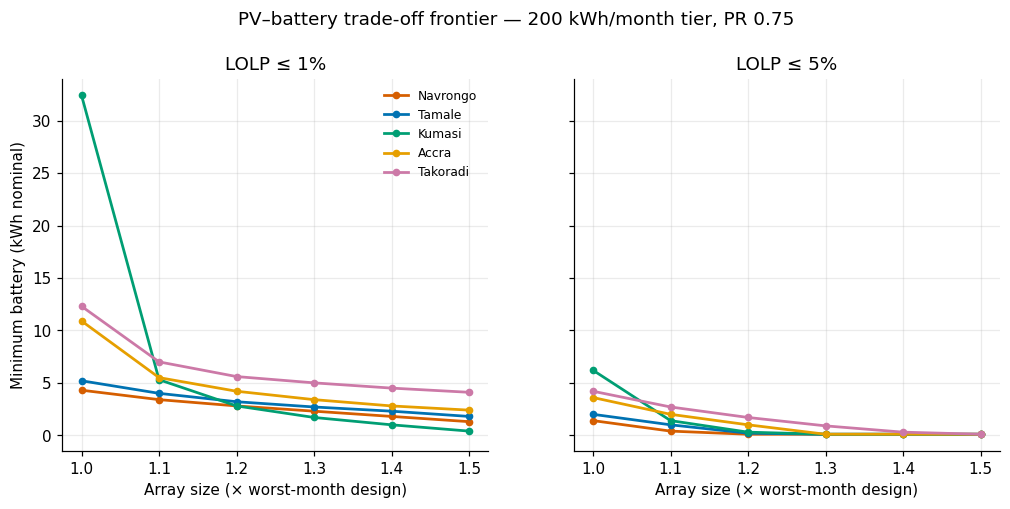

In [7]:
ARRAY_MULT = (1.0, 1.1, 1.2, 1.3, 1.4, 1.5)
frows = []
for key in SITE_ORDER:
    g = GHI[key].to_numpy()
    for m in ARRAY_MULT:
        gen = g * DESIGN_KWP[200] * m * PR_MAIN
        for target in LOLP_TARGETS:
            r = min_battery(gen, DAILY_LOAD[200], target)
            frows.append({'Site': SITE_LABEL[key], 'Array multiple': m,
                          'Array (kWp)': round(DESIGN_KWP[200] * m, 2),
                          'LOLP target': target,
                          'Battery (kWh nominal)': r['batt']})
frontier = pd.DataFrame(frows)
frontier.to_csv(RESULTS / 'sizing_frontier.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, target in zip(axes, LOLP_TARGETS):
    for key in SITE_ORDER:
        sub = frontier[(frontier['Site'] == SITE_LABEL[key])
                       & (frontier['LOLP target'] == target)]
        ax.plot(sub['Array multiple'], sub['Battery (kWh nominal)'],
                'o-', color=SITE_COLOR[key], label=SITE_LABEL[key], lw=1.8, ms=4)
    ax.set_title(f'LOLP ≤ {target:.0%}')
    ax.set_xlabel('Array size (× worst-month design)')
axes[0].set_ylabel('Minimum battery (kWh nominal)')
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle('PV–battery trade-off frontier — 200 kWh/month tier, PR 0.75', y=1.02)
fig.savefig(FIGDIR / 'fig_07_2_frontier.png')
plt.show()

## 7.5 The installer rule, and the low-sun runs that break it

The 2-day-autonomy rule prescribes the same battery everywhere (16.4 kWh nominal
at the 200 tier). The backtest scores the LOLP that rule actually achieves per
zone, and the low-sun run analysis (consecutive days with GHI < 3.5 kWh/m²/day,
the EDA day-type cutoff at which the battery, not the array, carries the
household) shows why a uniform rule cannot hold: worst runs of ~3 days in the
north versus ~6–7 on the coast. Saved to `installer_rule.csv`, `lowsun_runs.csv`;
Figures 7-3, 7-4.

2-day-autonomy installer rule, scored on 2005-2024:
    Site  Tier (kWh/mo)  Rule battery (kWh)  Achieved LOLP  Achieved LPSP  Required @5% (kWh)  Required @1% (kWh)  Rule vs 5% need (%)  Rule vs 1% need (%)
Navrongo            100                 8.2         0.0000         0.0000                 0.7                 2.2               1073.4                273.3
Navrongo            200                16.4         0.0000         0.0000                 1.4                 4.3               1073.4                282.0
Navrongo            300                24.6         0.0000         0.0000                 2.1                 6.4               1073.4                285.0
  Tamale            100                 8.2         0.0000         0.0000                 1.0                 2.6                721.4                215.9
  Tamale            200                16.4         0.0000         0.0000                 2.0                 5.2                721.4                215.9
  Tamale    

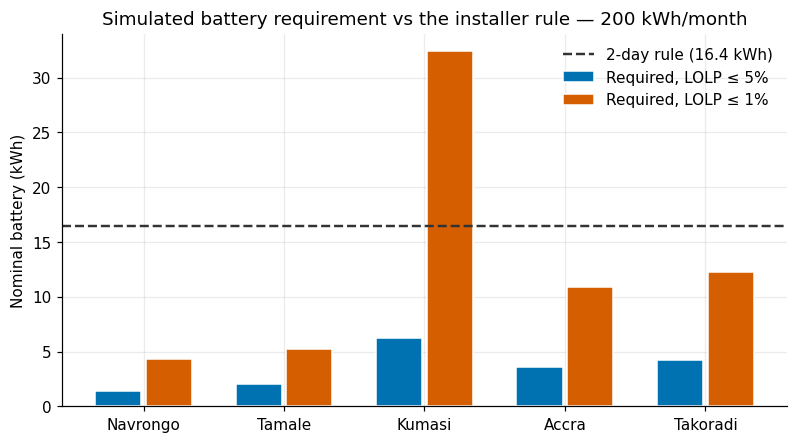

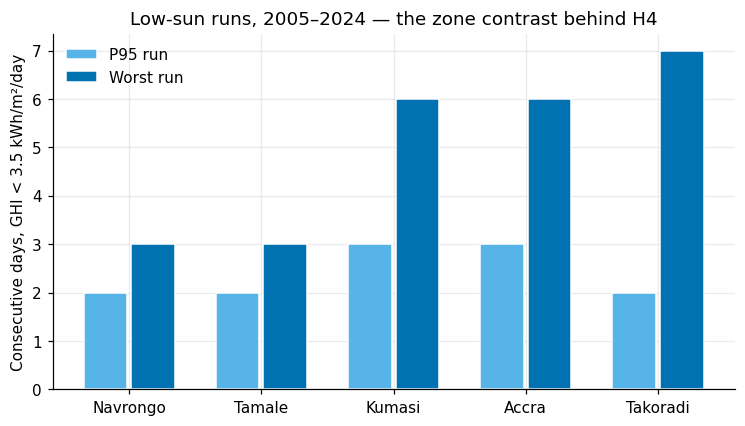

In [8]:
# ---- The installer rule scored against the record ---------------------------
irows = []
for key in SITE_ORDER:
    g = GHI[key].to_numpy()
    for t in TIERS:
        gen = g * DESIGN_KWP[t] * PR_MAIN
        caps = np.array([RULE_BATT[t]])
        lolp, lpsp, eens = sim_lolp_grid(gen, DAILY_LOAD[t], caps)
        need_5 = sizing[(sizing['Site'] == SITE_LABEL[key])
                        & (sizing['Tier (kWh/mo)'] == t)
                        & (sizing['LOLP target'] == 0.05)]['Battery (kWh nominal)'].iloc[0]
        need_1 = sizing[(sizing['Site'] == SITE_LABEL[key])
                        & (sizing['Tier (kWh/mo)'] == t)
                        & (sizing['LOLP target'] == 0.01)]['Battery (kWh nominal)'].iloc[0]
        irows.append({'Site': SITE_LABEL[key], 'Tier (kWh/mo)': t,
                      'Rule battery (kWh)': round(RULE_BATT[t], 1),
                      'Achieved LOLP': round(float(lolp[0]), 4),
                      'Achieved LPSP': round(float(lpsp[0]), 4),
                      'Required @5% (kWh)': need_5,
                      'Required @1% (kWh)': need_1,
                      'Rule vs 5% need (%)': round(100 * (RULE_BATT[t] - need_5) / need_5, 1),
                      'Rule vs 1% need (%)': round(100 * (RULE_BATT[t] - need_1) / need_1, 1)})
rule = pd.DataFrame(irows)
rule.to_csv(RESULTS / 'installer_rule.csv', index=False)
print('2-day-autonomy installer rule, scored on 2005-2024:')
print(rule.to_string(index=False), '\n')

# ---- Low-sun runs (GHI < 3.5 kWh/m²/day) ------------------------------------
lrows = []
for key in SITE_ORDER:
    low = (GHI[key] < LOWSUN_CUT).to_numpy().astype(int)
    runs, c = [], 0
    for v in low:
        if v:
            c += 1
        elif c:
            runs.append(c)
            c = 0
    if c:
        runs.append(c)
    runs = np.array(runs)
    lrows.append({'Site': SITE_LABEL[key],
                  'Low-sun days (%)': round(100 * low.mean(), 1),
                  'Runs >= 2 days': int((runs >= 2).sum()),
                  'P95 run (days)': int(np.percentile(runs, 95)) if len(runs) else 0,
                  'Worst run (days)': int(runs.max()) if len(runs) else 0})
lowsun = pd.DataFrame(lrows)
lowsun.to_csv(RESULTS / 'lowsun_runs.csv', index=False)
print('Consecutive low-sun runs (GHI < 3.5), 2005-2024:')
print(lowsun.to_string(index=False))

# ---- Figures ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.4))
xs = np.arange(len(SITE_ORDER))
sub = rule[rule['Tier (kWh/mo)'] == 200]
vals5 = [sub[sub['Site'] == SITE_LABEL[k]]['Required @5% (kWh)'].iloc[0] for k in SITE_ORDER]
vals1 = [sub[sub['Site'] == SITE_LABEL[k]]['Required @1% (kWh)'].iloc[0] for k in SITE_ORDER]
ax.bar(xs - 0.18, vals5, 0.33, color='#0072B2', label='Required, LOLP ≤ 5%',
       edgecolor='white')
ax.bar(xs + 0.18, vals1, 0.33, color='#D55E00', label='Required, LOLP ≤ 1%',
       edgecolor='white')
ax.axhline(RULE_BATT[200], color='#333333', lw=1.6, ls='--',
           label=f'2-day rule ({RULE_BATT[200]:.1f} kWh)')
ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER])
ax.set_ylabel('Nominal battery (kWh)')
ax.set_title('Simulated battery requirement vs the installer rule — 200 kWh/month')
ax.legend(frameon=False)
fig.savefig(FIGDIR / 'fig_07_3_installer_rule.png')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (col, colr, lab) in enumerate((('P95 run (days)', '#56B4E9', 'P95 run'),
                                      ('Worst run (days)', '#0072B2', 'Worst run'))):
    vals = [lowsun[lowsun['Site'] == SITE_LABEL[k]][col].iloc[0] for k in SITE_ORDER]
    ax.bar(xs + (i - 0.5) * 0.36, vals, 0.33, color=colr, label=lab, edgecolor='white')
ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER])
ax.set_ylabel('Consecutive days, GHI < 3.5 kWh/m²/day')
ax.set_title('Low-sun runs, 2005–2024 — the zone contrast behind H4')
ax.legend(frameon=False)
fig.savefig(FIGDIR / 'fig_07_4_lowsun_runs.png')
plt.show()

## 7.6 Sensitivity: performance ratio 0.70 / 0.75 / 0.80

The backtest is repeated with generation scaled by PR = 0.70 and 0.80 (array
fixed at the 0.75 design — the hardware does not change; the assumption about its
losses does). Saved to `sizing_sensitivity.csv`.

In [9]:
srows = []
for key in SITE_ORDER:
    g = GHI[key].to_numpy()
    for t in TIERS:
        for pr in PR_GRID:
            gen = g * DESIGN_KWP[t] * pr          # array fixed at PR-0.75 design
            for target in LOLP_TARGETS:
                r = min_battery(gen, DAILY_LOAD[t], target)
                srows.append({'Site': SITE_LABEL[key], 'Tier (kWh/mo)': t,
                              'PR': pr, 'LOLP target': target,
                              'Battery (kWh nominal)': r['batt']})
sens = pd.DataFrame(srows)
sens.to_csv(RESULTS / 'sizing_sensitivity.csv', index=False)

piv = sens[sens['Tier (kWh/mo)'] == 200].pivot_table(
    index=['LOLP target', 'PR'], columns='Site', values='Battery (kWh nominal)')
print('PR sensitivity — minimum nominal battery (kWh), 200 kWh/month tier:')
print(piv[[SITE_LABEL[k] for k in SITE_ORDER]].round(1))

PR sensitivity — minimum nominal battery (kWh), 200 kWh/month tier:
Site              Navrongo  Tamale  Kumasi  Accra  Takoradi
LOLP target PR                                             
0.01        0.70       5.2     8.6    76.2   35.2      25.5
            0.75       4.3     5.2    32.4   10.9      12.3
            0.80       3.6     4.3     9.4    6.5       8.3
0.05        0.70       2.2     3.3    41.3    6.9       6.1
            0.75       1.4     2.0     6.2    3.6       4.2
            0.80       0.7     1.3     2.0    2.4       3.1


## 7.7 Uncertainty and the H4 test

- **Moving-block bootstrap** (block = 30 days, ≈ 4× the longest observed low-sun
  run, B = 2,000) 95% CIs for the LOLP achieved by each chosen configuration.
- **Year-block bootstrap** (resampling the 20 calendar years with replacement,
  B = 1,000): the sizing search is re-run per replicate, giving 95% CIs for each
  site's required battery and for the **H4 statistic** — the percentage difference
  between the largest and smallest zone requirement at the 200 kWh/month tier.

Saved to `lolp_ci.csv`, `h4_test.csv`; Figure 7-1 shows the zone comparison with
year-block CIs.

Moving-block bootstrap 95% CIs for achieved LOLP (block = 30 days):
    Site  Tier (kWh/mo)  LOLP target  Battery (kWh nominal)  LOLP point  LOLP MBB 95% CI
Navrongo            200         0.01                    4.3      0.0096 [0.0066, 0.0127]
Navrongo            200         0.05                    1.4      0.0497 [0.0412, 0.0575]
  Tamale            200         0.01                    5.2      0.0099 [0.0063, 0.0140]
  Tamale            200         0.05                    2.0      0.0500 [0.0412, 0.0586]
  Kumasi            200         0.01                   32.4      0.0100 [0.0030, 0.0182]
  Kumasi            200         0.05                    6.2      0.0500 [0.0350, 0.0665]
   Accra            200         0.01                   10.9      0.0100 [0.0059, 0.0146]
   Accra            200         0.05                    3.6      0.0487 [0.0389, 0.0593]
Takoradi            200         0.01                   12.3      0.0100 [0.0053, 0.0153]
Takoradi            200         0.05      

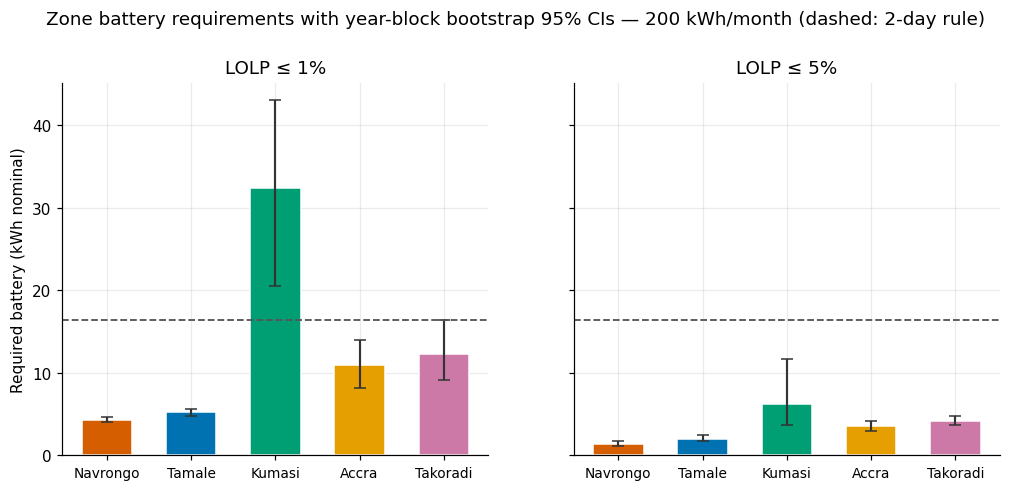

In [10]:
# ---- Moving-block bootstrap CI for the achieved LOLP (chosen configs) -------
def mbb_mean_ci(x, L=30, B=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    n = len(x)
    n_blocks = int(np.ceil(n / L))
    means = np.empty(B)
    for b in range(B):
        idx = np.concatenate([np.arange(s, s + L)
                              for s in rng.integers(0, n - L + 1, n_blocks)])[:n]
        means[b] = x[idx].mean()
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

ci_rows = []
for key in SITE_ORDER:
    g = GHI[key].to_numpy()
    for t in TIERS:
        gen = g * DESIGN_KWP[t] * PR_MAIN
        for target in LOLP_TARGETS:
            batt = sizing[(sizing['Site'] == SITE_LABEL[key])
                          & (sizing['Tier (kWh/mo)'] == t)
                          & (sizing['LOLP target'] == target)]['Battery (kWh nominal)'].iloc[0]
            loss = sim_one(gen, DAILY_LOAD[t], batt)
            lo, hi = mbb_mean_ci(loss)
            ci_rows.append({'Site': SITE_LABEL[key], 'Tier (kWh/mo)': t,
                            'LOLP target': target, 'Battery (kWh nominal)': batt,
                            'LOLP point': round(float(loss.mean()), 4),
                            'LOLP MBB 95% CI': f'[{lo:.4f}, {hi:.4f}]'})
lolp_ci = pd.DataFrame(ci_rows)
lolp_ci.to_csv(RESULTS / 'lolp_ci.csv', index=False)
print('Moving-block bootstrap 95% CIs for achieved LOLP (block = 30 days):')
print(lolp_ci[lolp_ci['Tier (kWh/mo)'] == 200].to_string(index=False), '\n')

# ---- Year-block bootstrap for required battery and the H4 statistic ---------
# Resample the 20 calendar years with replacement; re-run the sizing search per
# replicate (200 kWh/month tier). The SAME year draws are applied to every site
# (joint resampling preserves cross-site dependence, per synopsis v2.2), so the
# per-replicate zone ratios are properly paired. Checkpointed per site.
B_YEARS = 1000
year_idx = {y: np.where(GHI['accra'].index.year == y)[0] for y in YEARS}
DRAWS = np.random.default_rng(SEED).choice(YEARS, size=(B_YEARS, len(YEARS)),
                                           replace=True)

def boot_caps_for(key):
    point = {tg: sizing[(sizing['Site'] == SITE_LABEL[key])
                        & (sizing['Tier (kWh/mo)'] == 200)
                        & (sizing['LOLP target'] == tg)]['Battery (kWh nominal)'].iloc[0]
             for tg in LOLP_TARGETS}
    hi = max(point.values()) * 2.5 + 5
    return np.round(np.arange(0.1, hi + 0.1, 0.1), 1)

boot = {}
for key in SITE_ORDER:
    cpath = CACHE / f'boot_{key}.pkl'
    state = pickle.load(open(cpath, 'rb')) if cpath.exists() else \
        {'done': 0, 'b1': [], 'b5': []}
    if state['done'] < B_YEARS:
        g = GHI[key].to_numpy()
        caps = boot_caps_for(key)
        while state['done'] < B_YEARS:
            require_budget(25)
            t0 = time.time()
            while state['done'] < B_YEARS and time.time() - t0 < 15:
                yrs = DRAWS[state['done']]
                gb = np.concatenate([g[year_idx[y]] for y in yrs])
                gen = gb * DESIGN_KWP[200] * PR_MAIN
                lolp, _, _ = sim_lolp_grid(gen, DAILY_LOAD[200], caps)
                for tg, dest in ((0.01, 'b1'), (0.05, 'b5')):
                    ok = np.where(lolp <= tg)[0]
                    state[dest].append(float(caps[ok[0]]) if len(ok) else float(caps[-1]))
                state['done'] += 1
            with open(cpath, 'wb') as fh:
                pickle.dump(state, fh)
    boot[key] = state
    print(f"{SITE_LABEL[key]:<9} year-block bootstrap: {state['done']}/{B_YEARS} reps")

h4_rows = []
for tg, dest in ((0.01, 'b1'), (0.05, 'b5')):
    pts = {key: sizing[(sizing['Site'] == SITE_LABEL[key])
                       & (sizing['Tier (kWh/mo)'] == 200)
                       & (sizing['LOLP target'] == tg)]['Battery (kWh nominal)'].iloc[0]
           for key in SITE_ORDER}
    lo_k = min(pts, key=pts.get)
    hi_k = max(pts, key=pts.get)
    ratio = 100 * (pts[hi_k] - pts[lo_k]) / pts[lo_k]
    rboots = 100 * (np.array(boot[hi_k][dest]) - np.array(boot[lo_k][dest])) \
        / np.array(boot[lo_k][dest])
    ci = (float(np.percentile(rboots, 2.5)), float(np.percentile(rboots, 97.5)))
    for key in SITE_ORDER:
        bb = np.array(boot[key][dest])
        h4_rows.append({'LOLP target': tg, 'Site': SITE_LABEL[key],
                        'Battery (kWh nominal)': pts[key],
                        'Year-block 95% CI': f'[{np.percentile(bb, 2.5):.1f}, '
                                             f'{np.percentile(bb, 97.5):.1f}]'})
    h4_rows.append({'LOLP target': tg, 'Site': f'H4: {SITE_LABEL[hi_k]} vs {SITE_LABEL[lo_k]}',
                    'Battery (kWh nominal)': round(ratio, 1),
                    'Year-block 95% CI': f'[{ci[0]:.1f}, {ci[1]:.1f}] (%)'})
h4 = pd.DataFrame(h4_rows)
h4.to_csv(RESULTS / 'h4_test.csv', index=False)
print()
print(h4.to_string(index=False), '\n')

# ---- H4 adjudication (200 kWh/month tier) -----------------------------------
print('H4: required battery for a fixed reliability target differs across zones')
print('by >= 25% (materiality criterion; ~4 kWh at the 200 kWh/month tier).\n')
verdicts = {}
for tg, dest in ((0.05, 'b5'), (0.01, 'b1')):
    row = h4[(h4['LOLP target'] == tg) & (h4['Site'].str.startswith('H4:'))].iloc[0]
    ratio = row['Battery (kWh nominal)']
    ci_lo = float(row['Year-block 95% CI'].strip('[]( %)').split(',')[0])
    verdicts[tg] = ratio >= 25
    print(f"  LOLP {tg:.0%}: max-min zone difference = {ratio:.1f}% "
          f"(year-block 95% CI lower bound {ci_lo:.1f}%) -> "
          f"{'meets' if ratio >= 25 else 'does NOT meet'} the 25% criterion")
overall = ('SUPPORTED' if all(verdicts.values()) else
           'PARTIALLY SUPPORTED' if any(verdicts.values()) else 'NOT SUPPORTED')
print(f'\n  H4 verdict: {overall}')

# ---- Figure 7-1: zone comparison with year-block CIs (200 tier) -------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
xs = np.arange(len(SITE_ORDER))
for ax, (tg, dest) in zip(axes, ((0.01, 'b1'), (0.05, 'b5'))):
    for i, key in enumerate(SITE_ORDER):
        pt = sizing[(sizing['Site'] == SITE_LABEL[key])
                    & (sizing['Tier (kWh/mo)'] == 200)
                    & (sizing['LOLP target'] == tg)]['Battery (kWh nominal)'].iloc[0]
        bb = np.array(boot[key][dest])
        lo, hi = np.percentile(bb, 2.5), np.percentile(bb, 97.5)
        ax.bar(i, pt, 0.6, color=SITE_COLOR[key], edgecolor='white')
        ax.errorbar(i, pt, yerr=[[pt - lo], [hi - pt]], color='#333333',
                    capsize=4, lw=1.4)
    ax.axhline(RULE_BATT[200], color='#555555', lw=1.2, ls='--')
    ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER],
                                          fontsize=9)
    ax.set_title(f'LOLP ≤ {tg:.0%}')
axes[0].set_ylabel('Required battery (kWh nominal)')
fig.suptitle('Zone battery requirements with year-block bootstrap 95% CIs — '
             '200 kWh/month (dashed: 2-day rule)', y=1.03)
fig.savefig(FIGDIR / 'fig_07_1_zone_battery.png')
plt.show()

## 7.8 H4 verdict and what comes next

**H4: supported, decisively.** At the 200 kWh/month tier the required nominal
battery differs across zones by 342.9% at LOLP 5% (1.4 kWh Navrongo vs. 6.2
kWh Kumasi) and 653.5% at LOLP 1% (4.3 vs. 32.4 kWh); the joint year-block
bootstrap intervals ([143.7%, 776.9%] and [375.5%, 924.5%]) sit entirely above
the 25% materiality threshold.

Three readings matter for the recommendations:

1. **The binding zone is the forest, not the coast.** Kumasi's worst-month
   resource (~3.9 PSH) sits at the national design point, so its array runs
   chronically at the margin and reliability must be bought with storage; the
   coast has longer low-sun runs (worst 6-7 days) but a design margin that
   absorbs them.
2. **The 2-day installer rule fails in both directions**: LOLP 0.000 in the
   north (roughly ten times the 5% storage need, stranded capital) while
   missing the 1% target at Kumasi (achieved 2.7%).
3. **Reliability can be bought with panels instead of storage**: scaling
   Kumasi's array to 1.2x the design collapses its 1% battery requirement from
   32.4 to 2.8 kWh (Figure 7-2), the cheaper path at current component prices.

The PR sensitivity (0.70/0.75/0.80) bounds these numbers honestly: at PR 0.70
Kumasi's 1% requirement grows to 76 kWh, underscoring how close the national
design point sits to that zone's margin. With this notebook all four research
questions have executed analyses; the final report assembles them.